In [12]:
import scanpy as sc
import pandas as pd
import anndata as ad
from scipy.io import mmread

base_path = '/Users/lgolinelli/git/lineageVI/docs/data/Pancreas/extracted_data'

# Load each timepoint
timepoints = {
    'E12.5': 'GSM3852752_E12_5_counts',
    'E13.5': 'GSM3852753_E13_5_counts',
    'E14.5': 'GSM3852754_E14_5_counts',
    'E15.5': 'GSM3852755_E15_5_counts'
}

adata_list = []
for timepoint, dir_name in timepoints.items():
    dir_path = f'{base_path}/{dir_name}/mm10'
    matrix = mmread(f'{dir_path}/matrix.mtx').T.tocsr()  # Transpose: cells x genes
    genes = pd.read_csv(f'{dir_path}/genes.tsv', sep='\t', header=None)
    barcodes = pd.read_csv(f'{dir_path}/barcodes.tsv', sep='\t', header=None)
    
    adata = sc.AnnData(matrix)
    # Use gene ID (column 0) which is unique, store symbol in var metadata
    adata.var_names = genes[0].values  # Gene ID (unique)
    adata.var['gene_symbol'] = genes[1].values  # Gene symbols (may have duplicates)
    adata.obs_names = [f"{timepoint}_{barcode}" for barcode in barcodes[0].values]
    adata.obs['timepoint'] = timepoint
    
    adata_list.append(adata)

# Concatenate all timepoints using anndata.concat
# The 'batch' label will be created from the keys (timepoint names)
adata = ad.concat(adata_list, join='outer', label='batch', keys=list(timepoints.keys()))

print(f"Combined dataset: {adata.shape}")
print(f"Batches: {adata.obs['batch'].value_counts()}")

Combined dataset: (37977, 27998)
Batches: batch
E15.5    11439
E12.5    11183
E14.5    10188
E13.5     5167
Name: count, dtype: int64


/Users/lgolinelli/miniconda3/envs/test2/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/var/folders/1x/8dphwyvs0j504xrq138nfssh0000gn/T/ipykernel_20013/3837506305.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


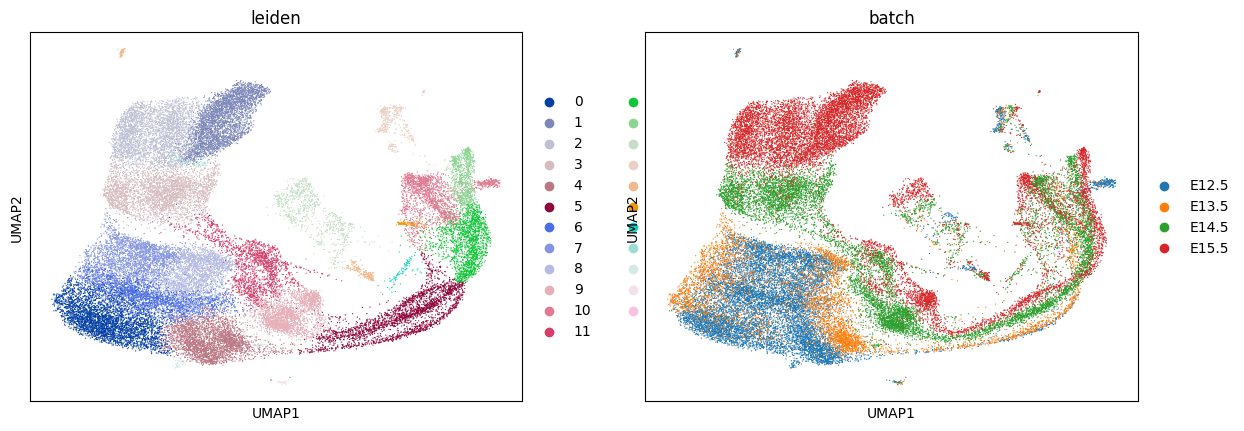

In [7]:
import scanpy as sc

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)

sc.pp.neighbors(adata)
sc.tl.leiden(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['leiden', 'batch'])

In [ ]:
# Save the processed data with spliced/unspliced layers
output_path = '/Users/lgolinelli/git/lineageVI/docs/data/Pancreas/pancreas_with_velocity.h5ad'
adata.write(output_path)
print(f"✓ Saved AnnData with spliced/unspliced layers to: {output_path}")
print(f"  Shape: {adata.shape}")
print(f"  Layers: {list(adata.layers.keys())}")
print(f"  Obs columns: {list(adata.obs.columns)}")


In [9]:
adata.X.data

array([1.4604189 , 0.9163785 , 0.9163785 , ..., 0.42008185, 1.9947945 ,
       1.6308761 ], shape=(10540549,), dtype=float32)